In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
import time
from io import StringIO
import geopandas as gpd
from difflib import get_close_matches

# 1) load CSV with caching
url = 'https://opendata.arcgis.com/datasets/bbb2e4f589ba40d692fab712ae37b9ac_1.csv'
cache = {}
CACHE_TTL = 3600  # 1 hour

def get_cached(key):
    entry = cache.get(key)
    if entry and time.time() - entry['time'] < CACHE_TTL:
        return entry['data']
    return None

def set_cache(key, data):
    cache[key] = {'data': data, 'time': time.time()}

cached_data = get_cached(url)
if cached_data is not None:
    df = cached_data
else:
    resp = requests.get(url)
    resp.raise_for_status()
    csv_text = resp.content.decode('utf-8-sig')
    df = pd.read_csv(StringIO(csv_text))
    df.columns = [c.lstrip('\ufeff').strip() for c in df.columns]
    set_cache(url, df)

print("✓ Data loaded. Columns:", df.columns.tolist())


✓ Data loaded. Columns: ['X', 'Y', 'OBJECTID', 'Province_State', 'Country_Region', 'Last_Update', 'Lat', 'Long_', 'Confirmed', 'Recovered', 'Deaths', 'Active', 'Admin2', 'FIPS', 'Combined_Key']


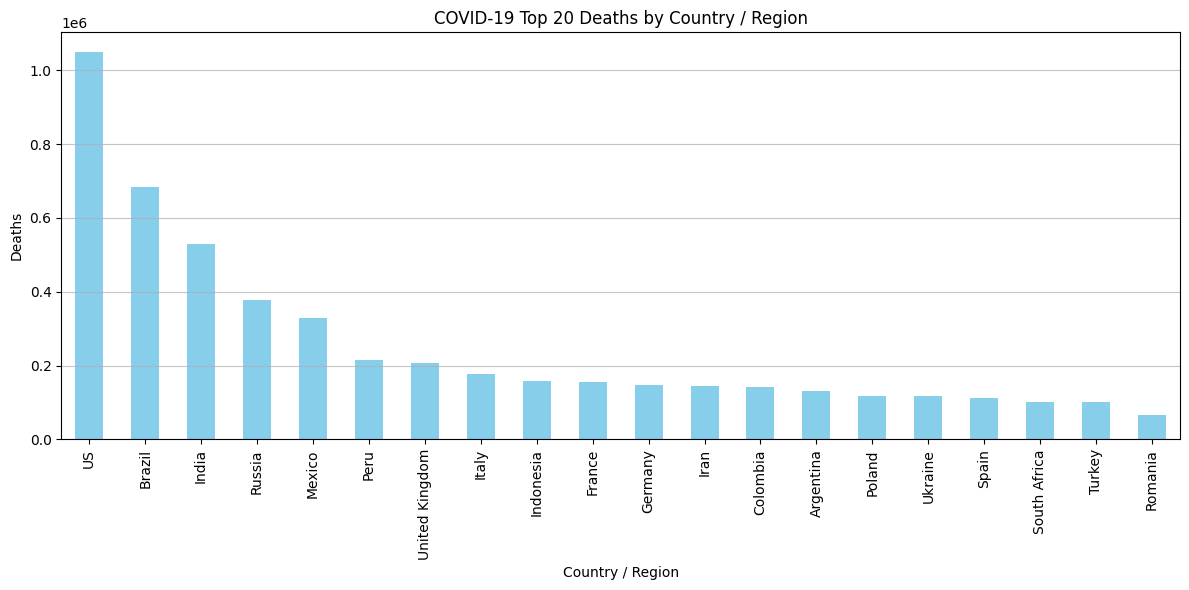

In [4]:
# Top 20 deaths by country (global overview)
region_col = 'Country_Region'
if 'Deaths' not in df.columns:
    raise KeyError(f"`Deaths` column not found. Columns: {df.columns.tolist()}")

# ensure Deaths is numeric
df['Deaths'] = pd.to_numeric(df['Deaths'], errors='coerce')
df['Deaths'] = df['Deaths'].fillna(0)
# aggregate into a DataFrame and sort properly
agg_deaths = df.groupby(region_col, as_index=False).agg({'Deaths': 'sum'})
top = agg_deaths.sort_values(by='Deaths', ascending=False).head(20)

ax = top.plot(kind='bar', x=region_col, y='Deaths', color='skyblue', figsize=(12, 6), legend=False)
ax.set_title('COVID-19 Top 20 Deaths by Country / Region')
ax.set_xlabel('Country / Region')
ax.set_ylabel('Deaths')
plt.xticks(rotation=90)
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()


In [5]:
# COVID API function (cached)
BASE = "https://covid-api.mmediagroup.fr/v1/"
_api_cache = {}
_CACHE_TTL = 600  # 10 minutes

def fetch_cases(country=None, ab=None, continent=None):
    """Fetch COVID cases from API with caching"""
    params = {}
    if ab:
        params["ab"] = ab
    elif continent:
        params["continent"] = continent
    elif country:
        params["country"] = country

    key = BASE + "?" + "&".join(f"{k}={v}" for k, v in sorted(params.items()))
    entry = _api_cache.get(key)
    if entry and time.time() - entry["time"] < _CACHE_TTL:
        return entry["data"].copy()

    resp = requests.get(BASE + "cases", params=params, timeout=10)
    resp.raise_for_status()
    data = resp.json()
    _api_cache[key] = {"data": data, "time": time.time()}
    return data

# Example: fetch France data
# result = fetch_cases(country="France")
# print(result)


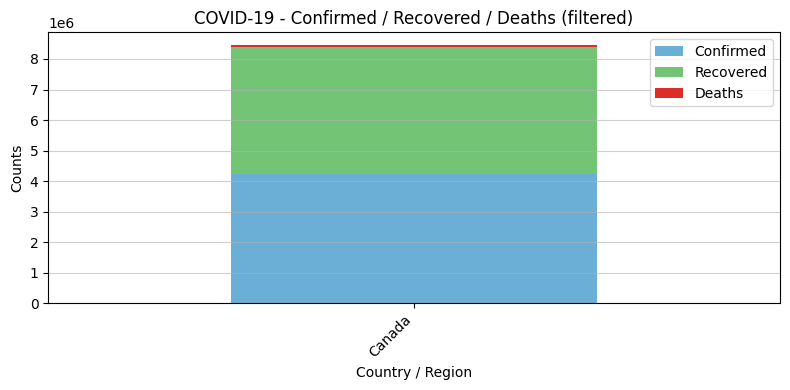

Map creation skipped: 'name'


In [6]:
# Search + filtered visualization + interactive map
region_col = 'Country_Region'
search = input("Enter region name to search in `Country_Region` (case-insensitive, leave blank for all): ").strip()

# Ensure numeric columns
for col in ['Confirmed', 'Deaths']:
    if col not in df.columns:
        df[col] = 0
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(0)

# Compute Recovered = Confirmed - Deaths
df['Recovered'] = (df['Confirmed'] - df['Deaths']).clip(lower=0).astype(int)

# Filter by search (exact first, then substring)
if search:
    qlow = search.lower()
    low = df[region_col].astype(str).str.lower()
    filtered = df[low == qlow]  # exact match
    if filtered.empty:
        filtered = df[low.str.contains(qlow, na=False)]  # substring fallback
else:
    filtered = df

if filtered.empty:
    raise ValueError(f"No rows match '{search}' in column `{region_col}`.")

# Aggregate by region (make explicit DataFrame and sums)
agg = filtered.groupby(region_col, as_index=False).agg({'Confirmed': 'sum', 'Recovered': 'sum', 'Deaths': 'sum'})
agg = agg.sort_values(by='Deaths', ascending=False)

# Plot stacked bar (only filtered results)
if len(agg) > 1:
    plot_data = agg.head(20)
    figsize = (12, 6)
else:
    plot_data = agg
    figsize = (8, 4)

plot_df = plot_data.set_index(region_col)[['Confirmed', 'Recovered', 'Deaths']]
ax = plot_df.plot(kind='bar', stacked=True, figsize=figsize, color=['#6baed6', '#74c476', '#de2d26'])
ax.set_title(f'COVID-19 - Confirmed / Recovered / Deaths{" (filtered)" if search else ""}')
ax.set_xlabel('Country / Region')
ax.set_ylabel('Counts')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.6)
plt.tight_layout()
plt.show()

# --- Interactive map (only filtered regions) ---
try:
    # Load world geometries directly from Natural Earth via URL (works with geopandas.read_file)
    world = gpd.read_file('https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip')
    world_names = world['name'].tolist()

    def best_world_match(region_name):
        """Match region name to world geometry (exact -> fuzzy -> None)"""
        if not isinstance(region_name, str):
            return None
        n = region_name.strip()
        nlow = n.lower()
        exact = [w for w in world_names if w.lower() == nlow]
        if exact:
            return exact[0]
        matches = get_close_matches(n, world_names, n=1, cutoff=0.7)
        return matches[0] if matches else None

    agg['world_name'] = agg[region_col].apply(best_world_match)
    agg_mapped = agg.dropna(subset=['world_name'])

    if not agg_mapped.empty:
        gdf = agg_mapped.merge(world[['name', 'geometry']], left_on='world_name', right_on='name', how='left')
        gdf = gpd.GeoDataFrame(gdf, geometry='geometry')

        m = gdf.explore(
            column='Deaths',
            cmap='Reds',
            legend=True,
            tooltip=[region_col, 'Confirmed', 'Recovered', 'Deaths'],
            tiles='CartoDB positron',
            style_kwds={'weight': 0.5, 'color': 'gray', 'fillOpacity': 0.7}
        )
        display(m)
    else:
        print(f"⚠ No matching geometries for '{search}'.")
except Exception as e:
    print(f"Map creation skipped: {e}")


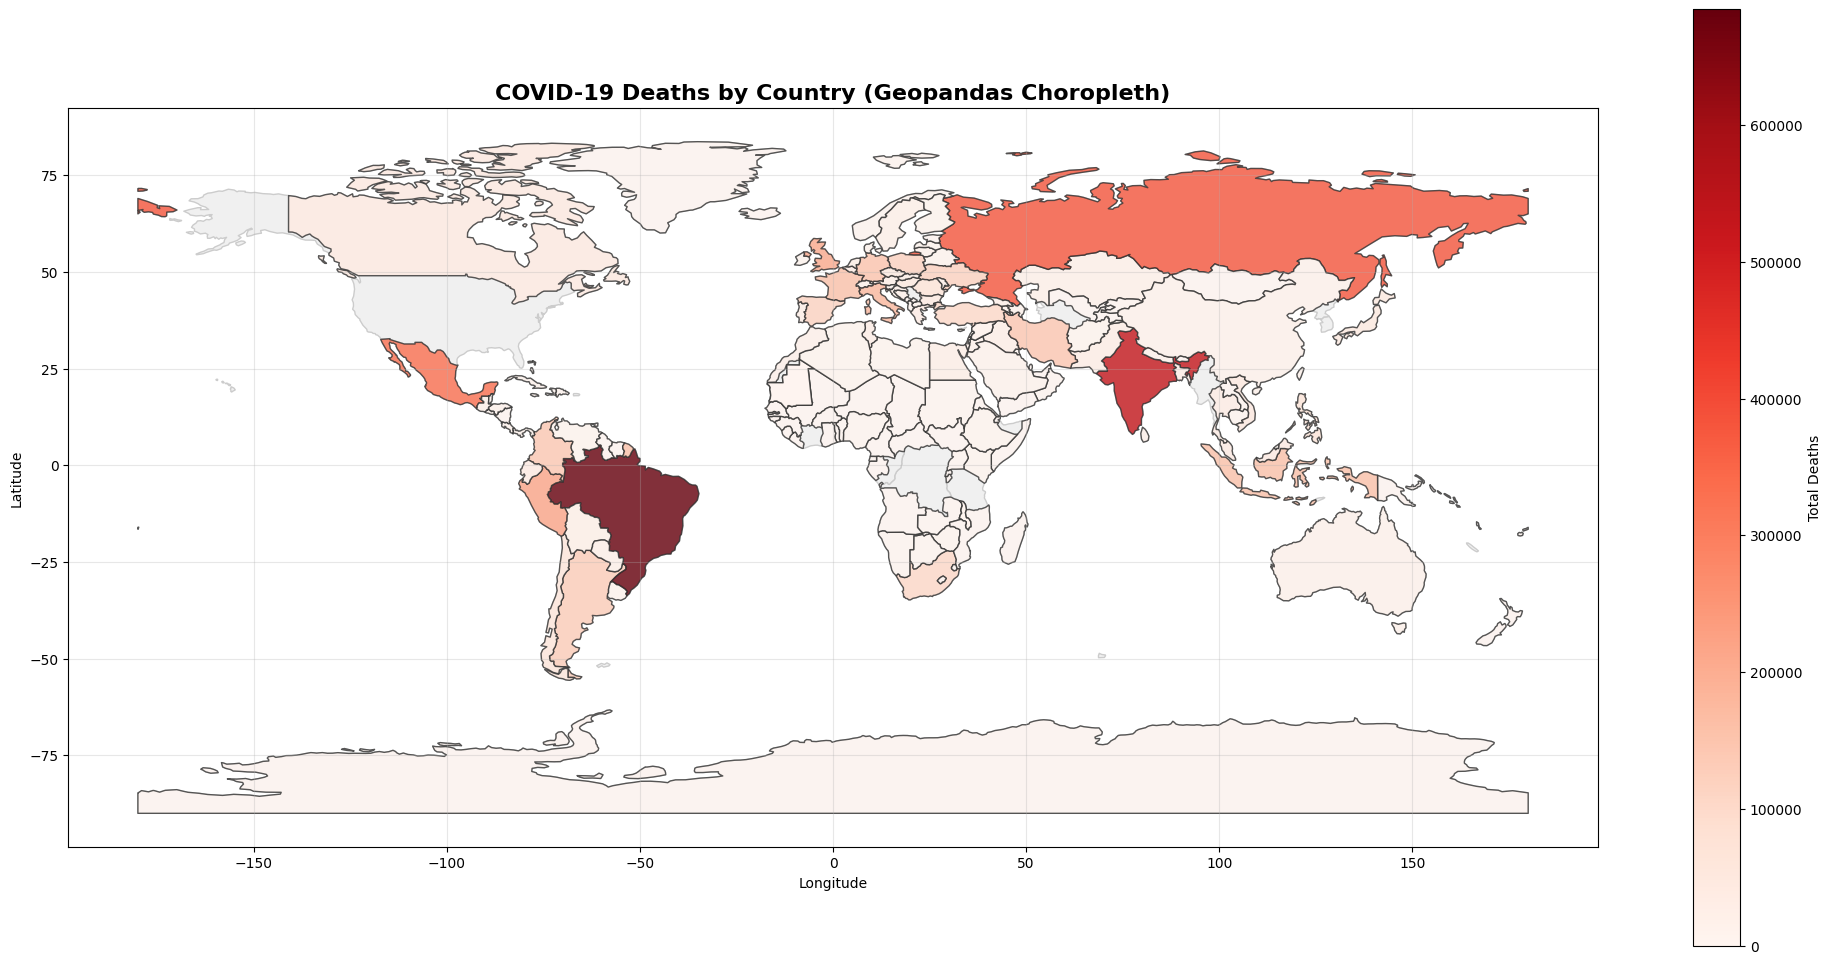


COVID-19 DATA SUMMARY
Total Countries with Data: 199
Total Confirmed Cases: 608,298,782
Total Recovered: 601,785,722
Total Deaths: 6,513,742
Mapped to World Geometries: 161


In [7]:
     # Interactive Geopandas Map Visualization
# Create a choropleth map showing COVID cases by country with full interactivity

import geopandas as gpd
import matplotlib.pyplot as plt

# Load world geometries directly from Natural Earth (via URL - no geodatasets needed)
world = gpd.read_file('https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip')

# Prepare COVID data: aggregate by country
covid_agg = df.groupby('Country_Region', as_index=False)[
    ['Confirmed', 'Recovered', 'Deaths', 'Lat', 'Long_']
].agg({
    'Confirmed': 'sum',
    'Recovered': 'sum',
    'Deaths': 'sum',
    'Lat': 'mean',
    'Long_': 'mean'
})

# Function to match COVID country names to world map country names
def match_country_name(covid_name):
    """Find best match between COVID dataset and world map country names"""
    if not isinstance(covid_name, str):
        return None

    covid_name_lower = covid_name.lower().strip()

    # Exact match (case-insensitive)
    for idx, row in world.iterrows():
        if row['ADMIN'].lower() == covid_name_lower:
            return row['ADMIN']

    # Fuzzy match with difflib
    from difflib import get_close_matches
    candidates = world['ADMIN'].tolist()
    matches = get_close_matches(covid_name, candidates, n=1, cutoff=0.7)
    return matches[0] if matches else None

# Apply matching
covid_agg['world_name'] = covid_agg['Country_Region'].apply(match_country_name)

# Merge COVID data with world geometries
world_covid = world.merge(
    covid_agg[['Country_Region', 'Confirmed', 'Recovered', 'Deaths', 'world_name']],
    left_on='ADMIN',
    right_on='world_name',
    how='left'
)

# Create the choropleth map
fig, ax = plt.subplots(figsize=(20, 12))

# Plot base map (all countries in light gray)
world_covid.plot(ax=ax, color='#f0f0f0', edgecolor='#cccccc')

# Plot countries with COVID data (colored by deaths)
world_covid_data = world_covid[world_covid['Deaths'].notna()]
world_covid_data.plot(
    ax=ax,
    column='Deaths',
    cmap='Reds',
    legend=True,
    legend_kwds={
        'label': 'Total Deaths',
        'orientation': 'vertical',
        'shrink': 0.8
    },
    edgecolor='#333333',
    alpha=0.8,
    vmin=0
)

ax.set_title('COVID-19 Deaths by Country (Geopandas Choropleth)', fontsize=16, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*60)
print("COVID-19 DATA SUMMARY")
print("="*60)
print(f"Total Countries with Data: {len(covid_agg)}")
print(f"Total Confirmed Cases: {covid_agg['Confirmed'].sum():,.0f}")
print(f"Total Recovered: {covid_agg['Recovered'].sum():,.0f}")
print(f"Total Deaths: {covid_agg['Deaths'].sum():,.0f}")
print(f"Mapped to World Geometries: {world_covid_data['Deaths'].notna().sum()}")
print("="*60)
